After Spark processes data from Kafka, it can save the results (frequent itemsets, association rules, etc.) to a CSV or Parquet file in an S3 bucket.

🔁 Combining Them in a Pipeline:
Stream from Kafka: Spark listens to Kafka for incoming transactions.

Process in Real Time: Spark applies FP-Growth to analyze purchase patterns.

Store Output to S3: Spark saves the results (e.g., frequent itemsets) into S3 for further use or visualization.

🧠 Real-World Use Case:
E-commerce platform uses Kafka to stream every cart/checkout event.

Spark processes this in real-time to identify trending product bundles.

Results are stored in S3 and visualized in Power BI or Tableau every hour.



Setting up Spark Environment Locally

In [3]:
!pip install pyspark
!pip install boto3


Importing Libraries

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import collect_list
from pyspark.ml.fpm import FPGrowth
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
import plotly.express as px


Step 2: Load CSV Data into Spark


In [7]:
# Initialize Spark Session
spark= SparkSession.builder.appName("MarketBasketAnalysis").getOrCreate()

#Load the csv file into Spark Dataframe
df=spark.read.csv("Groceries_dataset.csv",header=True,inferSchema=True)

#Show first few rows
df.show()

+-------------+----------+--------------------+
|Member_number|      Date|     itemDescription|
+-------------+----------+--------------------+
|         1808|21-07-2015|      tropical fruit|
|         2552|05-01-2015|          whole milk|
|         2300|19-09-2015|           pip fruit|
|         1187|12-12-2015|    other vegetables|
|         3037|01-02-2015|          whole milk|
|         4941|14-02-2015|          rolls/buns|
|         4501|08-05-2015|    other vegetables|
|         3803|23-12-2015|          pot plants|
|         2762|20-03-2015|          whole milk|
|         4119|12-02-2015|      tropical fruit|
|         1340|24-02-2015|        citrus fruit|
|         2193|14-04-2015|                beef|
|         1997|21-07-2015|         frankfurter|
|         4546|03-09-2015|             chicken|
|         4736|21-07-2015|              butter|
|         1959|30-03-2015|fruit/vegetable j...|
|         1974|03-05-2015|packaged fruit/ve...|
|         2421|02-09-2015|           cho

Step 3: Preprocess the Data
The dataset might require cleaning and preprocessing to fit the format that FP-Growth expects (a list of items per transaction).

In [8]:
df_grouped=df.groupby("Member_number","Date").agg(collect_list("itemDescription").alias("items"))
df_grouped.show()

+-------------+----------+--------------------+
|Member_number|      Date|               items|
+-------------+----------+--------------------+
|         1000|15-03-2015|[sausage, whole m...|
|         1000|24-06-2014|[whole milk, past...|
|         1000|24-07-2015|[canned beer, mis...|
|         1000|25-11-2015|[sausage, hygiene...|
|         1000|27-05-2015|[soda, pickled ve...|
|         1001|02-05-2015| [frankfurter, curd]|
|         1001|07-02-2014|[sausage, whole m...|
|         1001|12-12-2014|  [whole milk, soda]|
|         1001|14-04-2015| [beef, white bread]|
|         1001|20-01-2015|[frankfurter, sod...|
|         1002|09-02-2014|[frozen vegetable...|
|         1002|26-04-2014|[butter, whole milk]|
|         1002|26-04-2015|[tropical fruit, ...|
|         1002|30-08-2015|[butter milk, spe...|
|         1003|10-02-2015|[sausage, rolls/b...|
|         1003|15-10-2014|[root vegetables,...|
|         1003|19-01-2014|[frozen meals, de...|
|         1003|27-02-2014|[rolls/buns, r

This step ensures that each row in your DataFrame represents a single transaction with a list of items purchased.

 Run FP-Growth to Find Frequent Itemsets
Now that your data is ready, you can run FP-Growth to identify frequent itemsets. 

1) itemsCol='items' - This tells the algorithm which column in your data contains the lists of items to analyze. It's looking for a column named 'items' that has collections of things (like products in shopping baskets).

2) minSupport=0.01 - This sets how common a pattern needs to be for the algorithm to care about it. The value 0.01 (or 1%) means "only show me patterns that appear in at least 1% of all transactions." This filters out very rare combinations.

3) minConfidence=0.5 - This sets how strong a relationship needs to be to be reported. The value 0.5 (or 50%) means "only show me relationships where if item A appears, there's at least a 50% chance item B also appears."

Support looks at how common something is across ALL transactions
Confidence looks at how often B happens WHEN A happens (it's conditional)

Why is This Important?
Removing Duplicates: We remove duplicates from each transaction to ensure that the FPGrowth algorithm does not incorrectly count an item multiple times within the same transaction. For example, if a customer buys two loaves of bread, we want it to count as just one occurrence of bread.

Fitting the Model: The FPGrowth algorithm is applied to identify frequent patterns in the data. It finds frequent itemsets based on support and generates association rules based on confidence.

Results: The frequent itemsets can help understand which items tend to be bought together, and this information can be useful for things like market basket analysis, product placement in stores, and recommendation systems.

Because FP-Growth expects:

A list of distinct items per transaction.

If you don’t do this, items bought multiple times in one transaction are over-counted within that transaction — which breaks the logic of the algorithm.

Let’s say we have this data (before array_distinct):

Transaction ID	Items
T1	[milk, milk, bread]
T2	[milk, bread, eggs]
T3	[milk, eggs]

Without array_distinct, T1 has "milk" twice.
But FP-Growth would wrongly treat this like "milk" is more important in T1.

➡️ This inflates the item’s support in one transaction.

🔁 After array_distinct:
Transaction ID	Items
T1	[milk, bread]
T2	[milk, bread, eggs]
T3	[milk, eggs]

Now each item appears once per transaction, and:

Milk appears in 3 transactions

Bread appears in 2

Eggs appears in 2

✅ This is exactly what we want:
How many transactions include the item, not how many times it's repeated within one.

📌 So in short:
FP-Growth counts transaction frequency, not repetition within one transaction.

That's why removing duplicates with array_distinct is correct and necessary.

1. Frequent Itemsets
FP-Growth first finds all combinations of items (1-item, 2-item, etc.) that meet the minSupport threshold.

2. Association Rules
Next, FP-Growth uses the frequent itemsets to generate association rules, like:

scss
Copy
Edit
milk ⇒ bread (confidence = 0.67)
This means:

"Out of all transactions that had milk, 67% also had bread."

This uses your minConfidence setting (e.g., 0.5 = 50%) to decide which rules are strong enough to keep.

In [9]:
df_grouped_unique = df_grouped.withColumn("items", F.array_distinct(df_grouped["items"]))
# Fit the FPGrowth model again on the cleaned data
fp_growth = FPGrowth(itemsCol="items", minSupport=0.01, minConfidence=0.1)
model = fp_growth.fit(df_grouped_unique)

# Get the frequent itemsets
frequent_itemsets = model.freqItemsets
# Show the frequent itemsets
frequent_itemsets.show(truncate=False)

+------------------------------+----+
|items                         |freq|
+------------------------------+----+
|[beef]                        |508 |
|[white wine]                  |175 |
|[chocolate]                   |353 |
|[sugar]                       |265 |
|[oil]                         |223 |
|[processed cheese]            |152 |
|[candy]                       |215 |
|[meat]                        |252 |
|[frankfurter]                 |565 |
|[sausage]                     |903 |
|[berries]                     |326 |
|[coffee]                      |473 |
|[pip fruit]                   |734 |
|[hygiene articles]            |205 |
|[salty snack]                 |281 |
|[white bread]                 |359 |
|[specialty chocolate]         |239 |
|[domestic eggs]               |555 |
|[rolls/buns]                  |1646|
|[rolls/buns, other vegetables]|158 |
+------------------------------+----+
only showing top 20 rows



Extract Association Rules

Once the frequent Itemsets are generated,we can create association rules using the frequent Itemsets 

In [10]:
# Get the association Rules
association_rules=model.associationRules

#  Show the association Rules
association_rules.show(truncate=False)

+------------------+------------+-------------------+------------------+--------------------+
|antecedent        |consequent  |confidence         |lift              |support             |
+------------------+------------+-------------------+------------------+--------------------+
|[other vegetables]|[whole milk]|0.12151067323481117|0.7694304712706219|0.014836596939116486|
|[yogurt]          |[whole milk]|0.12996108949416343|0.8229402378760761|0.011160863463209249|
|[rolls/buns]      |[whole milk]|0.12697448359659783|0.8040284376030019|0.013967787208447505|
|[soda]            |[whole milk]|0.11975223675154852|0.7582956912879478|0.011628684087415625|
+------------------+------------+-------------------+------------------+--------------------+



These rules will tell you which items tend to be bought together (e.g., if you buy bread, you're likely to buy butter).

Visualize the Results
Visualize the frequent itemsets or association rules, you can convert the results into a Pandas DataFrame and use Matplotlib or Seaborn for plotting.



#### Visualization

#Convert to pandas Dataframe for visualization 
frequent_itemsets_pd=frequent_itemsets.toPandas() 
#Plot the top 10 frequent itemsets by frequency
sns.barplot(x='freq',y='items',data=frequent_itemsets_pd.head(10))


Convert frequent_itemsets to Pandas

This allows you to use libraries like matplotlib, seaborn, or plotly.


In [11]:
###### Convert to Pandas
frequent_itemsets = frequent_itemsets.toPandas()


Sort & Select Top Frequent Itemsets

Visualize the most frequent combinations

In [12]:
# Sort by frequency and select top N
top_itemsets=frequent_itemsets.sort_values(by='freq',ascending=False).head(10)
top_itemsets

,items,freq
68,[whole milk],2363
42,[other vegetables],1827
18,[rolls/buns],1646
58,[soda],1453
28,[yogurt],1285
21,[root vegetables],1041
66,[tropical fruit],1014
34,[bottled water],908
9,[sausage],903
53,[citrus fruit],795


#### Bar Chart of Top Frequent Itemsets

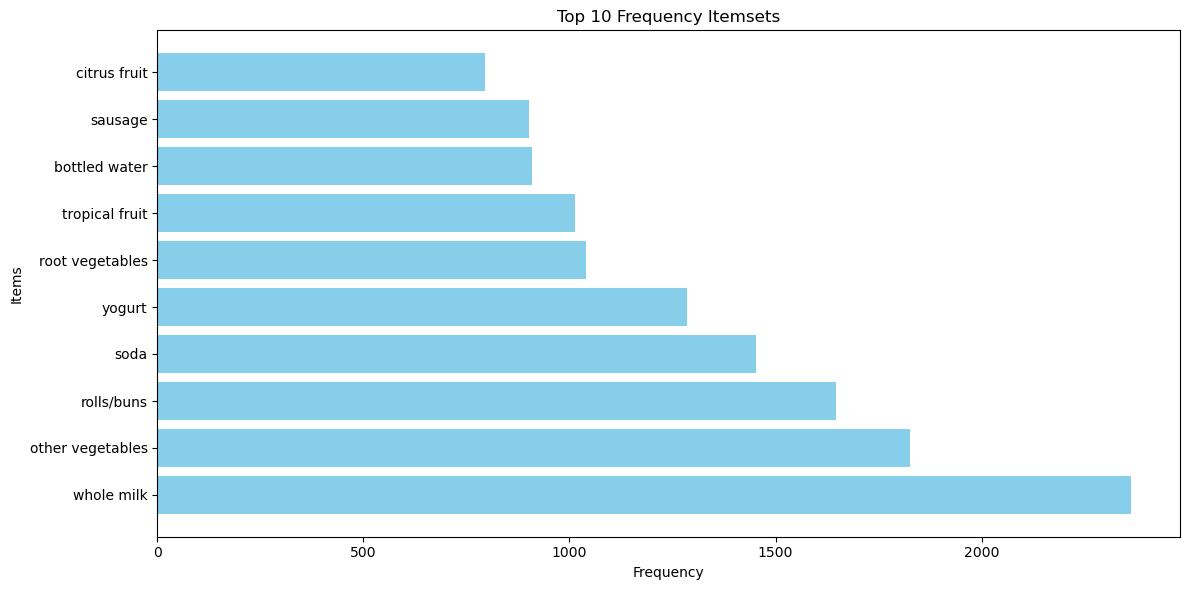

In [13]:
#convert listof items to string 
# Ensure all itemsets are tuples instead of lists
frequent_itemsets['items'] = frequent_itemsets['items'].apply(lambda x: tuple(x))
# Convert list/tuple in 'items' column to a clean string
frequent_itemsets['item_str'] = frequent_itemsets['items'].apply(
    lambda x: ', '.join([str(i) for i in x])
)

top_itemsets = frequent_itemsets.sort_values(by="freq", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_itemsets['item_str'],top_itemsets['freq'],color='skyblue')
plt.xlabel('Frequency')
plt.ylabel("Items")
plt.title("Top 10 Frequency Itemsets")
plt.tight_layout()
plt.show()

#### Visualizing Association Rules 

When you extract association rules, columns like antecedents and consequents are stored as frozensets, which also cause TypeError: 'value' must be an instance of str or bytes, not a tuple/frozenset.

##### Convert frozensets to strings for plotting

In [14]:
print(association_rules.columns)


['antecedent', 'consequent', 'confidence', 'lift', 'support']


In [15]:
# convert frozenset column to string
from pyspark.sql import functions as F

# Convert the frozenset to string by using PySpark's array_join function
association_rules = association_rules.withColumn("antecedent_str", F.array_join("antecedent", ", "))
association_rules = association_rules.withColumn("consequent_str", F.array_join("consequent", ", "))

# Show the updated DataFrame with new columns
association_rules.show()



+------------------+------------+-------------------+------------------+--------------------+----------------+--------------+
|        antecedent|  consequent|         confidence|              lift|             support|  antecedent_str|consequent_str|
+------------------+------------+-------------------+------------------+--------------------+----------------+--------------+
|[other vegetables]|[whole milk]|0.12151067323481117|0.7694304712706219|0.014836596939116486|other vegetables|    whole milk|
|          [yogurt]|[whole milk]|0.12996108949416343|0.8229402378760761|0.011160863463209249|          yogurt|    whole milk|
|      [rolls/buns]|[whole milk]|0.12697448359659783|0.8040284376030019|0.013967787208447505|      rolls/buns|    whole milk|
|            [soda]|[whole milk]|0.11975223675154852|0.7582956912879478|0.011628684087415625|            soda|    whole milk|
+------------------+------------+-------------------+------------------+--------------------+----------------+--------

Why Convert Antecedents and Consequents to Strings?
Interpretability in Visualization:

Antecedents and consequents represent itemsets, typically as lists or sets of items (e.g., {milk, bread}).

For visualization purposes (like plotting in a bar chart), these itemsets need to be in a human-readable format. Converting them into strings (e.g., "milk, bread") allows you to display them easily in labels on the axes of plots, making it clearer what items are part of the rule.

A string like "milk, bread" is much more readable and interpretable for users than a list, like ['milk', 'bread'], which might be harder to read in a chart or graph. It also helps in organizing and filtering data when using visual tools like matplotlib.

Categorical Representation:

In the case of rules, the antecedent and consequent are categorical data points that need to be displayed in a format that can easily be matched to their corresponding values (i.e., their lift and confidence).

The string format enables easy comparison across rules and makes it possible to neatly display each item combination in charts, especially when working with tools like matplotlib or seaborn for visualizing bar charts.

Why Leave Lift and Confidence as Numerical Values?
Numeric Evaluation:

Lift and confidence are continuous numeric variables, not categorical. These metrics represent the strength and reliability of the association rule.

In visualizations like bar charts or scatter plots, numeric values (like lift and confidence) need to stay in their original numerical form for accurate representation and analysis.

For example, lift values directly indicate the strength of an association: if lift > 1, it means the items are more likely to appear together than by chance; a lift of 1 means there’s no association; and if it’s < 1, the items are less likely to appear together.

Confidence quantifies the probability of finding the consequent given the antecedent. These numeric metrics are essential to understand the quality of the rules.

Visualization Fit:

Lift and confidence are plotted on numeric axes because they are continuous values. If you were to convert them into strings, it would obscure their meaning as continuous variables and might make it harder to assess the strength of the associations.

For example, a heatmap or scatter plot works best with continuous numeric values to show the correlation between lift, confidence, and the items in the rules.

#### Plot: Scatter plot of lift vs confidence


In [17]:
fig = px.scatter(
   association_rules,
    x="confidence",
    y="lift",
    size="support",
    color="lift",
    hover_data=["antecedent_str", "consequent_str", "support", "confidence", "lift"],
    title="Association Rules: Confidence vs Lift"
)
fig.show()


Heatmap of 2-Item Frequent Itemsets

C:\Users\pc\AppData\Local\Temp\ipykernel_14276\2130789105.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\pc\AppData\Local\Temp\ipykernel_14276\2130789105.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



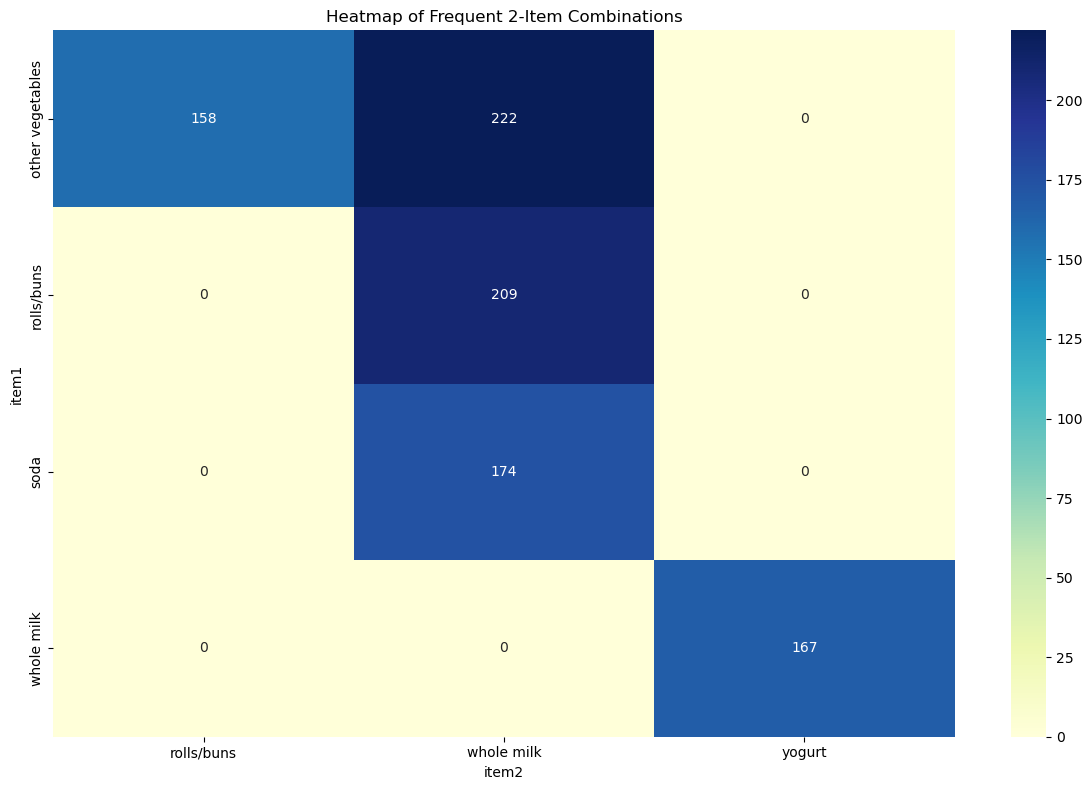

In [18]:
# Filter 2-item sets
itemsets_2 = frequent_itemsets[frequent_itemsets['items'].apply(lambda x: len(x) == 2)]

# Create item1 and item2 columns
itemsets_2['item1'] = itemsets_2['items'].apply(lambda x: sorted(x)[0])
itemsets_2['item2'] = itemsets_2['items'].apply(lambda x: sorted(x)[1])

# Pivot to create a heatmap matrix
heatmap_data = itemsets_2.pivot(index='item1', columns='item2', values='freq').fillna(0)

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of Frequent 2-Item Combinations")
plt.tight_layout()
plt.show()
